### Importacion de Librerias

In [32]:
import sys
!{sys.executable} -m pip install openpyxl
import pandas as pd
pd.set_option('display.max_columns', None)

In [33]:
data2023 = pd.read_excel("../data/raw/2023_113_Reporte.xlsx")
data2024 = pd.read_excel("../data/raw/2024_113_Reporte.xlsx")
data2025 = pd.read_excel("../data/raw/2025_113_Reporte.xlsx")

In [34]:
datasets = {
    "2023": data2023,
    "2024": data2024,
    "2025": data2025,
}

### Filtrar edades fuera del estudio

In [35]:
# El evento 113 aplica a menores de 5 anios.
# uni_med_=1 -> anios; uni_med_=2 -> meses.
# Se conservan registros en meses (siempre < 5 anios) o en anios con edad_ <= 5.
for year, df in datasets.items():
    if "edad_" in df.columns and "uni_med_" in df.columns:
        mask = (df["uni_med_"] == 2) | ((df["uni_med_"] == 1) & (df["edad_"] <= 5))
        datasets[year] = df[mask].copy()
    print(f"{year}: {datasets[year].shape[0]} filas despues del filtro de edad")

2023: 106 filas despues del filtro de edad
2024: 1432 filas despues del filtro de edad
2025: 1049 filas despues del filtro de edad


### Valores nulos (diagnostico inicial)

In [36]:
for year, df in datasets.items():
    print(f"\n=== {year} ===")
    print(df.isnull().sum().sort_values(ascending=False).head(15))


=== 2023 ===
fm_unidad                        106
cer_def_                         106
otra_orien                       106
otra_ident                       106
estrato_datos_complementarios    106
fm_fuerza                        106
sem_ges_                         106
cbmte_                           106
RegIniFec                        106
fm_grado                         106
iden_gener                       105
orient_sex                       105
cen_pobla_                       104
uni_modif                        101
nuni_modif                       101
dtype: int64

=== 2024 ===
fm_unidad                        1432
sem_ges_                         1432
RegIniFec                        1432
fm_grado                         1432
otra_ident                       1432
estrato_datos_complementarios    1432
cbmte_                           1432
cer_def_                         1432
fm_fuerza                        1432
otra_orien                       1429
lat_dir                 

### Eliminar columnas irrelevantes o 100% nulas

In [37]:
cols_drop = [
    "otra_ident", "sem_ges_", "cer_def_", "cbmte_",
    "fm_fuerza", "fm_unidad", "fm_grado",
    "estrato_datos_complementarios", "RegIniFec"
]

for year, df in datasets.items():
    datasets[year] = df.drop(columns=cols_drop, errors="ignore")
    print(f"{year}: {datasets[year].shape[1]} columnas despues de eliminar columnas innecesarias")

2023: 117 columnas despues de eliminar columnas innecesarias
2024: 117 columnas despues de eliminar columnas innecesarias
2025: 117 columnas despues de eliminar columnas innecesarias


## Correccion de tipos de datos

Inspeccion del dataset original revelo que varias columnas numericas vienen como texto
con **coma como separador decimal** (formato es-CO: `14,70`, `-2,1066`, `7,4`).
Algunas filas de esas mismas columnas son enteros puros (`45`, `10`).
Esto hace que pandas las lea como `object` (str) en lugar de `float64`.

El patron correcto es:
1. `.astype(str).str.strip()` — homogeneiza a texto.
2. `.str.replace(',', '.', regex=False)` — convierte coma decimal a punto.
3. `pd.to_numeric(..., errors='coerce')` — convierte a float; deja NaN si hay texto no numerico.

**NO** usar `.str.replace(',', '.')` directamente en columnas que ya son float64
(ej. `peso_nac`, `edad_ges`) pues el punto ya es el separador y la conversion es correcta.

Columnas afectadas identificadas en la inspeccion del dataset 2023:
| Columna | Descripcion | Problema |
|---------|-------------|----------|
| `peso_act` | Peso actual (kg) | Mix enteros + coma decimal (`7,4`, `10`) |
| `talla_act` | Talla actual (cm) | Mix enteros + coma decimal (`70,5`, `68`) |
| `per_braqui` | Circunferencia media del brazo (cm) | Mix enteros + coma decimal |
| `imc` | IMC (kg/m2) | Mix enteros + coma decimal (`14,70`, `10`) |
| `zscore_pt` | Z-score peso/talla | Siempre coma decimal (`-2,1066`) |
| `zscore_te` | Z-score talla/edad | Siempre coma decimal (`-2,1914`) |

### Conversion de columnas con coma decimal

In [38]:
# Columnas que en el dataset original usan coma como separador decimal.
# talla_nac tambien llega como str con coma decimal (ej. '49,5') y mezcla enteros ('40') y floats ('40.0').
cols_coma_decimal = ["peso_act", "talla_act", "talla_nac", "per_braqui", "imc", "zscore_pt", "zscore_te"]

for year, df in datasets.items():
    for col in cols_coma_decimal:
        if col in df.columns:
            # Paso 1: str para homogeneizar (enteros puros y decimales con coma conviven)
            # Paso 2: sustituir coma por punto
            # Paso 3: convertir a float — errors='coerce' deja NaN si hay texto no convertible
            df[col] = pd.to_numeric(
                df[col].astype(str).str.strip().str.replace(",", ".", regex=False),
                errors="coerce"
            )
    datasets[year] = df

# Verificar tipos resultantes
for year, df in datasets.items():
    cols_presentes = [c for c in cols_coma_decimal if c in df.columns]
    print(f"\n=== {year} - tipos despues de conversion ===")
    print(df[cols_presentes].dtypes)
    print("NaN por columna:")
    print(df[cols_presentes].isna().sum())
    print("Rangos:")
    print(df[cols_presentes].agg(["min", "max"]))


=== 2023 - tipos despues de conversion ===
peso_act      float64
talla_act     float64
talla_nac       int64
per_braqui    float64
imc           float64
zscore_pt     float64
zscore_te     float64
dtype: object
NaN por columna:
peso_act      0
talla_act     0
talla_nac     0
per_braqui    0
imc           0
zscore_pt     0
zscore_te     0
dtype: int64
Rangos:
     peso_act  talla_act  talla_nac  per_braqui    imc  zscore_pt  zscore_te
min       2.3       45.0          0         0.0   10.0    -5.2786    -9.1475
max      46.0       98.5         55        14.5  123.6    17.2444     7.3506

=== 2024 - tipos despues de conversion ===
peso_act      float64
talla_act     float64
talla_nac     float64
per_braqui    float64
imc           float64
zscore_pt     float64
zscore_te     float64
dtype: object
NaN por columna:
peso_act      1
talla_act     1
talla_nac     1
per_braqui    1
imc           1
zscore_pt     1
zscore_te     1
dtype: int64
Rangos:
     peso_act  talla_act  talla_nac  per_braq

### Correccion de talla_nac y reemplazo de 0 por NaN

- `talla_nac` llega como `object` con mix de enteros puros (`'40'`) y decimales con coma (`'49,5'`). Requiere la misma conversion coma->punto que las demas columnas numericas.
- Campos donde 0 = 'no registrado' segun rangos validos de la ficha:
  - `peso_nac`: valido 900-5000 g | `talla_nac`: valido 30-55 cm
  - `per_braqui`: valido 6-30 cm  | `edad_ges`: valido 20-45 semanas

In [39]:
# 1. Convertir talla_nac de str (con posible coma decimal) a float64
for year, df in datasets.items():
    if "talla_nac" in df.columns:
        df["talla_nac"] = pd.to_numeric(
            df["talla_nac"].astype(str).str.strip().str.replace(",", ".", regex=False),
            errors="coerce"
        )
    datasets[year] = df

# 2. Reemplazar 0 por NaN en campos donde 0 = 'no registrado'
cols_cero_es_nulo = ["peso_nac", "talla_nac", "per_braqui", "edad_ges"]

for year, df in datasets.items():
    for col in cols_cero_es_nulo:
        if col in df.columns:
            n = (df[col] == 0).sum()
            df[col] = df[col].replace(0, float("nan"))
            if n > 0:
                print(f"{year} | {col}: {n} ceros reemplazados por NaN")
    datasets[year] = df

2023 | peso_nac: 17 ceros reemplazados por NaN
2023 | talla_nac: 71 ceros reemplazados por NaN
2023 | per_braqui: 18 ceros reemplazados por NaN
2023 | edad_ges: 6 ceros reemplazados por NaN
2024 | peso_nac: 12 ceros reemplazados por NaN
2024 | talla_nac: 913 ceros reemplazados por NaN
2024 | per_braqui: 116 ceros reemplazados por NaN
2024 | edad_ges: 6 ceros reemplazados por NaN
2025 | peso_nac: 22 ceros reemplazados por NaN
2025 | talla_nac: 603 ceros reemplazados por NaN
2025 | per_braqui: 138 ceros reemplazados por NaN
2025 | edad_ges: 7 ceros reemplazados por NaN


## Tratamiento de outliers

Rangos validos segun la ficha de notificacion y criterios clinicos para menores de 5 anios.

#### Peso actual (1 - 25 kg)

In [40]:
for year, df in datasets.items():
    if "peso_act" in df.columns:
        antes = len(df)
        datasets[year] = df[(df["peso_act"] >= 1) & (df["peso_act"] <= 25)]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por peso_act fuera de [1, 25] kg")

2023: 1 filas eliminadas por peso_act fuera de [1, 25] kg
2024: 3 filas eliminadas por peso_act fuera de [1, 25] kg
2025: 3 filas eliminadas por peso_act fuera de [1, 25] kg


#### Talla actual (45 - 150 cm)

In [41]:
for year, df in datasets.items():
    if "talla_act" in df.columns:
        antes = len(df)
        datasets[year] = df[(df["talla_act"] >= 45) & (df["talla_act"] <= 150)]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por talla_act fuera de [45, 150] cm")

2023: 0 filas eliminadas por talla_act fuera de [45, 150] cm
2024: 0 filas eliminadas por talla_act fuera de [45, 150] cm
2025: 0 filas eliminadas por talla_act fuera de [45, 150] cm


#### IMC (10 - 30 kg/m2)

In [42]:
for year, df in datasets.items():
    if "imc" in df.columns:
        antes = len(df)
        datasets[year] = df[(df["imc"] >= 10) & (df["imc"] <= 30)]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por imc fuera de [10, 30]")

2023: 1 filas eliminadas por imc fuera de [10, 30]
2024: 16 filas eliminadas por imc fuera de [10, 30]
2025: 10 filas eliminadas por imc fuera de [10, 30]


#### Z-score peso/talla imposible (< -6 o > 5)

In [43]:
for year, df in datasets.items():
    if "zscore_pt" in df.columns:
        antes = len(df)
        datasets[year] = df[(df["zscore_pt"] >= -6) & (df["zscore_pt"] <= 5)]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por zscore_pt fuera de [-6, 5]")

2023: 0 filas eliminadas por zscore_pt fuera de [-6, 5]
2024: 1 filas eliminadas por zscore_pt fuera de [-6, 5]
2025: 4 filas eliminadas por zscore_pt fuera de [-6, 5]


#### Z-score talla/edad imposible (< -6 o > 6)

In [44]:
# La OMS establece que z-scores fuera de [-6, 6] indican error de medicion.
# zscore_pt ya se filtro arriba; zscore_te requiere el mismo tratamiento.
for year, df in datasets.items():
    if "zscore_te" in df.columns:
        antes = len(df)
        datasets[year] = df[(df["zscore_te"] >= -6) & (df["zscore_te"] <= 6)]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por zscore_te fuera de [-6, 6]")

2023: 6 filas eliminadas por zscore_te fuera de [-6, 6]
2024: 48 filas eliminadas por zscore_te fuera de [-6, 6]
2025: 23 filas eliminadas por zscore_te fuera de [-6, 6]


#### Error en clasificacion (clas_peso = 7)

In [45]:
for year, df in datasets.items():
    if "clas_peso" in df.columns:
        antes = len(df)
        datasets[year] = df[df["clas_peso"] != 7]
        print(f"{year}: {antes - len(datasets[year])} filas eliminadas por clas_peso == 7")

2023: 0 filas eliminadas por clas_peso == 7
2024: 2 filas eliminadas por clas_peso == 7
2025: 0 filas eliminadas por clas_peso == 7


### Conversion a entero de columnas categoricas (1/2 y clasificaciones)

Estas columnas son enteras en la ficha pero pandas las lee como `float64` porque el Excel
tiene celdas vacias que introducen NaN. Una vez eliminadas las filas invalidas ya no tienen
NaN y se pueden castear a `Int64` (entero nullable de pandas). Esto evita que aparezcan
como `1.0` / `2.0` en lugar de `1` / `2`.

In [46]:
cols_enteras = [
    "clas_peso",        # 1=Normal ... 6=Sobrepeso
    "clas_talla",       # 1=Normal, 2=Riesgo, 3=Baja talla
    "edema",            # 1=Si, 2=No
    "delgadez",         # 1=Si, 2=No
    "palidez",          # 1=Si, 2=No
    "piel_rese",        # 1=Si, 2=No
    "hiperpigm",        # 1=Si, 2=No
    "cambios_cabello",  # 1=Si, 2=No
]

for year, df in datasets.items():
    for col in cols_enteras:
        if col in df.columns:
            # Int64 (mayuscula) = entero nullable de pandas: soporta NaN sin convertir a float
            df[col] = df[col].astype("Int64")
    datasets[year] = df

for year, df in datasets.items():
    cols_pres = [c for c in cols_enteras if c in df.columns]
    print(f"\n=== {year} — tipos columnas enteras ===")
    print(df[cols_pres].dtypes)
    print("Valores unicos (ejemplo edema):", df["edema"].unique() if "edema" in df.columns else "N/A")


=== 2023 — tipos columnas enteras ===
clas_peso          Int64
clas_talla         Int64
edema              Int64
delgadez           Int64
palidez            Int64
piel_rese          Int64
hiperpigm          Int64
cambios_cabello    Int64
dtype: object
Valores unicos (ejemplo edema): <IntegerArray>
[2, 1]
Length: 2, dtype: Int64

=== 2024 — tipos columnas enteras ===
clas_peso          Int64
clas_talla         Int64
edema              Int64
delgadez           Int64
palidez            Int64
piel_rese          Int64
hiperpigm          Int64
cambios_cabello    Int64
dtype: object
Valores unicos (ejemplo edema): <IntegerArray>
[2, 1]
Length: 2, dtype: Int64

=== 2025 — tipos columnas enteras ===
clas_peso          Int64
clas_talla         Int64
edema              Int64
delgadez           Int64
palidez            Int64
piel_rese          Int64
hiperpigm          Int64
cambios_cabello    Int64
dtype: object
Valores unicos (ejemplo edema): <IntegerArray>
[2, 1]
Length: 2, dtype: Int64


### Revision de nulos y rangos post-filtros

In [47]:
cols_check = ["peso_act", "talla_act", "talla_nac", "per_braqui", "imc", "zscore_pt", "zscore_te"]
for year, df in datasets.items():
    cols_presentes = [c for c in cols_check if c in df.columns]
    print(f"\n=== {year} ===")
    print(df[cols_presentes].isnull().sum().rename("NaN"))
    print(df[cols_presentes].agg(["min", "max"]))


=== 2023 ===
peso_act       0
talla_act      0
talla_nac     65
per_braqui    17
imc            0
zscore_pt      0
zscore_te      0
Name: NaN, dtype: int64
     peso_act  talla_act  talla_nac  per_braqui    imc  zscore_pt  zscore_te
min       2.3       48.0       40.0         6.0  10.00    -5.2786    -5.9574
max      18.5       98.5       55.0        14.5  19.07     2.5164     4.2623

=== 2024 ===
peso_act        0
talla_act       0
talla_nac     875
per_braqui     95
imc             0
zscore_pt       0
zscore_te       0
Name: NaN, dtype: int64
     peso_act  talla_act  talla_nac  per_braqui   imc  zscore_pt  zscore_te
min       2.4       48.0       30.0         6.0  10.0    -5.9643    -5.9964
max      16.5      104.5       55.0        18.0  21.9     2.8940     4.4536

=== 2025 ===
peso_act        0
talla_act       0
talla_nac     584
per_braqui    128
imc             0
zscore_pt       0
zscore_te       0
Name: NaN, dtype: int64
     peso_act  talla_act  talla_nac  per_braqui   imc  z

## Validacion y conversion de fechas

In [48]:
cols_fecha = [
    "fec_not", "fecha_nto_", "FechaHora",
    "ini_sin_", "fec_con_", "fec_def_", "fec_hos_"
]

for year, df in datasets.items():
    for col in cols_fecha:
        if col in df.columns:
            # dayfirst=True porque el formato de la ficha es dd/mm/aaaa
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
    datasets[year] = df
    print(f"{year}: fechas convertidas")

2023: fechas convertidas
2024: fechas convertidas
2025: fechas convertidas


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6172\1790054646.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_6172\1790054646.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")


### Validacion de edad vs. fecha de nacimiento

In [49]:
for year, df in datasets.items():
    requeridas = ["fec_not", "fecha_nto_", "edad_", "uni_med_"]
    if all(c in df.columns for c in requeridas):
        df = df.copy()
        df["_edad_calc_anios"] = (df["fec_not"] - df["fecha_nto_"]).dt.days / 365
        # Convertir edad registrada a anios para comparar
        df["_edad_anios"] = df["edad_"].where(df["uni_med_"] == 1, df["edad_"] / 12)
        antes = len(df)
        df = df[abs(df["_edad_anios"] - df["_edad_calc_anios"]) < 1]
        df = df.drop(columns=["_edad_calc_anios", "_edad_anios"])
        datasets[year] = df
        print(f"{year}: {antes - len(df)} filas eliminadas por inconsistencia edad/fecha")
    else:
        print(f"{year}: columnas de fecha/edad no disponibles, validacion omitida")

2023: 1 filas eliminadas por inconsistencia edad/fecha
2024: 12 filas eliminadas por inconsistencia edad/fecha
2025: 8 filas eliminadas por inconsistencia edad/fecha


## Limpieza de variables categoricas

In [50]:
for year, df in datasets.items():
    if "sexo_" in df.columns:
        df["sexo_"] = df["sexo_"].astype(str).str.upper().str.strip()
        df["sexo_"] = df["sexo_"].replace({"MASCULINO": "M", "FEMENINO": "F"})
    datasets[year] = df
    vals = datasets[year]["sexo_"].unique() if "sexo_" in datasets[year].columns else "N/A"
    print(f"{year}: sexo_ limpiado — valores unicos: {vals}")

2023: sexo_ limpiado — valores unicos: ['M' 'F']
2024: sexo_ limpiado — valores unicos: ['F' 'M']
2025: sexo_ limpiado — valores unicos: ['F' 'M']


## Imputacion de valores nulos

In [51]:
for year, df in datasets.items():
    # peso_nac: imputar por mediana del grupo (edad_ges) para reducir el sesgo
    # de la mediana global que deja 33% de filas con el mismo valor artificial.
    if "peso_nac" in df.columns:
        if "edad_ges" in df.columns:
            df["peso_nac"] = df.groupby("edad_ges")["peso_nac"].transform(
                lambda x: x.fillna(x.median())
            )
        # Fallback: si quedaron NaN sin grupo, usar mediana global
        df["peso_nac"] = df["peso_nac"].fillna(df["peso_nac"].median())
    # edad_ges: imputar con mediana (ya no tiene ceros tras el paso anterior)
    if "edad_ges" in df.columns:
        df["edad_ges"] = df["edad_ges"].fillna(df["edad_ges"].median())
    # estrato_: usar 0 (entero) en lugar de 'Desconocido' para mantener tipo numerico
    if "estrato_" in df.columns:
        df["estrato_"] = pd.to_numeric(df["estrato_"], errors="coerce").fillna(0).astype(int)
    datasets[year] = df
    print(f"{year}: imputacion completada")

2023: imputacion completada
2024: imputacion completada
2025: imputacion completada


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## Creacion de columnas derivadas

Se crean columnas con etiquetas legibles a partir de los codigos numericos/geograficos
para facilitar el analisis descriptivo y la visualizacion.

In [52]:
# ─── 1. per_etn_ → etnia (etiqueta legible) ───────────────────────────────
mapa_etnia = {
    1: "Indigena",
    2: "Rom, Gitano",
    3: "Raizal",
    4: "Palenquero",
    5: "Negro, mulato, afrocolombiano",
    6: "Otro",
}

# ─── 2. estrato_: float → int, NaN/Desconocido → moda ────────────────────
# (operacion por año para que la moda sea representativa de cada dataset)

# ─── 3. cod_pais_o → pais_origen ─────────────────────────────────────────
mapa_pais = {
    170: "Colombia",
    862: "Venezuela",
}

# ─── 4. cod_dpto_o → depto_origen ────────────────────────────────────────
mapa_dpto = {
    "44": "La Guajira",
    "08": "Atlantico",
    "11": "Bogota D.C.",
    "13": "Bolivar",
    "20": "Cesar",
    "47": "Magdalena",
    "54": "Norte de Santander",
    "70": "Sucre",
    "D0": "Extranjero",   # codigo SIVIGILA para pacientes extranjeros
    "25": "Cundinamarca",
    "15": "Boyaca",
    "52": "Narino",
    "68": "Santander",
}

# ─── 5. cod_mun_o → municipio_origen (municipios del Cesar) ──────────────
mapa_municipio = {
    1:   "Valledupar",
    13:  "Agustin Codazzi",
    32:  "Astrea",
    45:  "Becerril",
    60:  "Bosconia",
    175: "Chimichagua",
    178: "Chiriquana",
    228: "Curumani",
    238: "El Copey",
    250: "El Paso",
    295: "Gamarra",
    383: "La Gloria",
    400: "La Jagua de Ibirico",
    517: "Pailitas",
    550: "Pelaya",
    570: "Pueblo Bello",
    614: "Rio de Oro",
    621: "La Paz (Robles)",
    710: "San Alberto",
    750: "San Diego",
    770: "San Martin",
    787: "Tamalameque",
    850: "Manaure Balcon del Cesar",
    873: "Gonzalez",

    # Nuevos municipios
    35:  "Albania",
    53:  "Aracataca",
    78:  "Barrancas",
    90:  "Dibulla",
    98:  "Distraccion",
    110: "El Molino",
    189: "Cienaga",
    279: "Fonseca",
    288: "Fundacion",
    378: "Hatonuevo",
    430: "Maicao",
    464: "Momil",
    560: "Manaure",
    650: "San Juan del Cesar",
    660: "Sabanas de San Angel",
    798: "Tenerife",
    835: "Turmeque",
    847: "Uribia",
    874: "Villanueva",

    # municipios de otros departamentos pueden quedar como codigo numerico
    # si no estan en el mapa
}

for year, df in datasets.items():
    df = df.copy()

    # 1. Columna derivada de per_etn_
    if "per_etn_" in df.columns:
        df["etnia"] = df["per_etn_"].map(mapa_etnia)

    # 1b. nom_grupo_: nombre del grupo etnico especifico (ej. "Arhuaco", "Wayuu")
    #     La columna ya existe en el Excel original con el nombre del grupo.
    #     Se limpia y normaliza (strip + title case) para estandarizar valores.
    if "nom_grupo_" in df.columns:
        df["nom_grupo_"] = (
            df["nom_grupo_"]
            .astype(str)
            .str.strip()
            .str.title()
            .replace({"Nan": pd.NA, "None": pd.NA, "": pd.NA})
        )

    # 2. estrato_: float → int, reemplazar NaN por moda
    if "estrato_" in df.columns:
        # Convertir a numerico (elimina 'Desconocido' si quedara como str)
        df["estrato_"] = pd.to_numeric(df["estrato_"], errors="coerce")
        moda_estrato = int(df["estrato_"].mode()[0])
        df["estrato_"] = df["estrato_"].fillna(moda_estrato).astype(int)
        print(f"{year} | estrato_: moda = {moda_estrato}")

    # 3. Columna derivada de cod_pais_o
    if "cod_pais_o" in df.columns:
        df["pais_origen"] = df["cod_pais_o"].map(mapa_pais).fillna("Otro")

    # 4. Columna derivada de cod_dpto_o
    if "cod_dpto_o" in df.columns:
        # cod_dpto_o puede venir como int o str segun el año
        dpto_str = df["cod_dpto_o"].astype(str).str.strip().str.zfill(2)
        df["depto_origen"] = dpto_str.map(mapa_dpto).fillna("Otro departamento")

    # 5. Columna derivada de cod_mun_o
    if "cod_mun_o" in df.columns:
        df["municipio_origen"] = df["cod_mun_o"].map(mapa_municipio).fillna(
            df["cod_mun_o"].astype(str)
        )

    datasets[year] = df

# Verificacion rapida
df_muestra = datasets[list(datasets.keys())[0]]
cols_nuevas = [c for c in ["etnia", "nom_grupo_", "estrato_", "pais_origen", "depto_origen", "municipio_origen"] if c in df_muestra.columns]
print("\nColumnas derivadas creadas:", cols_nuevas)
for col in cols_nuevas:
    print(f"\n{col}:")
    print(df_muestra[col].value_counts().sort_index().to_string())

2023 | estrato_: moda = 1
2024 | estrato_: moda = 1
2025 | estrato_: moda = 1

Columnas derivadas creadas: ['etnia', 'nom_grupo_', 'estrato_', 'pais_origen', 'depto_origen', 'municipio_origen']

etnia:
etnia
Indigena    88
Otro         9

nom_grupo_:
nom_grupo_
Arhuaco    18
Kogui       2
Wayuu      43
Wiwa        2
Yukpa      22

estrato_:
estrato_
0     1
1    94
2     2

pais_origen:
pais_origen
Colombia    97

depto_origen:
depto_origen
Cesar         42
La Guajira    52
Magdalena      3

municipio_origen:
municipio_origen
Agustin Codazzi       20
Albania                2
Becerril               1
Dibulla                2
Maicao                 9
Manaure                9
Pueblo Bello          19
San Juan del Cesar     1
Uribia                18
Valledupar            15
Villanueva             1


## Seleccion optima de variables

In [53]:
demograficas = [
    "edad_", "uni_med_", "sexo_",
    "nacionali_", "per_etn_", "etnia",   # etnia: etiqueta legible de per_etn_
    "nom_grupo_",                              # nombre del grupo etnico especifico
    "estrato_",
]

geograficas = [
    "cod_pais_o", "pais_origen",           # pais_origen: etiqueta de cod_pais_o
    "cod_dpto_o", "depto_origen",          # depto_origen: nombre del departamento
    "cod_mun_o",  "municipio_origen",      # municipio_origen: nombre del municipio
    "area_",
    "cod_pais_r", "cod_dpto_r", "cod_mun_r"
]

clinicas = [
    "peso_nac", "talla_nac", "edad_ges",
    "peso_act", "talla_act", "per_braqui",
    "imc", "zscore_pt", "zscore_te",
    "clas_peso", "clas_talla",
    "edema", "delgadez", "palidez",
    "piel_rese", "hiperpigm", "cambios_cabello"
]


## Dataset final

### Correccion final de tipos

**1. `talla_nac`** — puede quedar como `object` con mezcla de enteros (`'40'`), decimales con coma (`'49,5'`) y ceros. Se convierte a `float64` y los ceros se marcan como `NaN`.

**2. Columnas categoricas** (`clas_peso`, `clas_talla`, `edema`, `delgadez`, `palidez`, `piel_rese`, `hiperpigm`, `cambios_cabello`) — quedan como `float64` con `.0` porque pandas usa float cuando hay NaN en columnas de enteros. Se convierten a `Int64` (entero nullable) para eliminar los `.0` sin perder los NaN.

In [54]:
# talla_nac: convertir a float64 y limpiar ceros residuales
for year, df in datasets.items():
    if "talla_nac" in df.columns:
        df["talla_nac"] = pd.to_numeric(
            df["talla_nac"].astype(str).str.strip().str.replace(",", ".", regex=False),
            errors="coerce"
        )
        n_ceros = (df["talla_nac"] == 0).sum()
        df["talla_nac"] = df["talla_nac"].replace(0, float("nan"))
        print(f"{year} | talla_nac: dtype={df['talla_nac'].dtype}, {n_ceros} ceros -> NaN, NaN total={df['talla_nac'].isna().sum()}")
    datasets[year] = df

2023 | talla_nac: dtype=float64, 0 ceros -> NaN, NaN total=65
2024 | talla_nac: dtype=float64, 0 ceros -> NaN, NaN total=867
2025 | talla_nac: dtype=float64, 0 ceros -> NaN, NaN total=578


In [55]:
# Columnas categoricas ordinales: float64 con .0 -> Int64 (entero nullable de pandas)
cols_categoricas_int = [
    "clas_peso", "clas_talla",
    "edema", "delgadez", "palidez",
    "piel_rese", "hiperpigm", "cambios_cabello"
]

for year, df in datasets.items():
    for col in cols_categoricas_int:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    datasets[year] = df
    cols_ok = [c for c in cols_categoricas_int if c in datasets[year].columns]
    print(f"{year}: categoricas -> {datasets[year][cols_ok].dtypes.unique()}",
          "| NaN clas_peso:", datasets[year]["clas_peso"].isna().sum() if "clas_peso" in datasets[year].columns else "N/A")

2023: categoricas -> [Int64Dtype()] | NaN clas_peso: 0
2024: categoricas -> [Int64Dtype()] | NaN clas_peso: 9
2025: categoricas -> [Int64Dtype()] | NaN clas_peso: 0


In [56]:
cols_finales = demograficas + geograficas + clinicas

for year, df in datasets.items():
    cols_disponibles = [c for c in cols_finales if c in df.columns]
    datasets[year] = df[cols_disponibles].copy()
    print(f"{year} - Shape final: {datasets[year].shape}")

data2023 = datasets["2023"]
data2024 = datasets["2024"]
data2025 = datasets["2025"]

2023 - Shape final: (97, 35)
2024 - Shape final: (1350, 35)
2025 - Shape final: (1001, 35)


## Resumen final de todos los datasets

In [57]:
for year, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"  DATASET {year} - RESUMEN FINAL")
    print(f"{'='*50}")

    filas, columnas = df.shape
    print(f" Filas    : {filas}")
    print(f" Columnas : {columnas}")

    nulos_totales = df.isnull().sum().sum()
    pct = (nulos_totales / (filas * columnas) * 100) if filas * columnas > 0 else 0
    print(f" Nulos    : {nulos_totales} ({pct:.2f}%)")

    nulos_col = df.isnull().sum().sort_values(ascending=False)
    nulos_col = nulos_col[nulos_col > 0]
    if not nulos_col.empty:
        print(" Columnas con nulos remanentes:")
        print(nulos_col.to_string())
    else:
        print(" Sin valores nulos.")

    print("\n Tipos de datos:")
    print(df.dtypes.to_string())
    print("\n Estadisticas descriptivas:")
    display(df.describe())
    print("\n Primeras 5 filas:")
    display(df.head())


  DATASET 2023 - RESUMEN FINAL
 Filas    : 97
 Columnas : 35
 Nulos    : 92 (2.71%)
 Columnas con nulos remanentes:
talla_nac     65
per_braqui    17
nom_grupo_    10

 Tipos de datos:
edad_                 int64
uni_med_              int64
sexo_                object
nacionali_            int64
per_etn_              int64
etnia                object
nom_grupo_           object
estrato_              int32
cod_pais_o            int64
pais_origen          object
cod_dpto_o            int64
depto_origen         object
cod_mun_o             int64
municipio_origen     object
area_                 int64
cod_pais_r            int64
cod_dpto_r            int64
cod_mun_r             int64
peso_nac            float64
talla_nac           float64
edad_ges            float64
peso_act            float64
talla_act           float64
per_braqui          float64
imc                 float64
zscore_pt           float64
zscore_te           float64
clas_peso             Int64
clas_talla            Int64
ed

,edad_,uni_med_,nacionali_,per_etn_,estrato_,cod_pais_o,cod_dpto_o,cod_mun_o,area_,cod_pais_r,cod_dpto_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
count,97.000000,97.000000,97.0,97.000000,97.000000,97.0,97.000000,97.000000,97.000000,97.0,97.000000,97.000000,97.000000,32.000000,97.000000,97.000000,97.000000,80.00000,97.000000,97.000000,97.000000,97.0,97.0,97.0,97.0,97.0,97.0,97.0,97.0
mean,2.783505,1.268041,170.0,1.463918,1.010309,170.0,33.701031,382.268041,2.608247,170.0,34.195876,378.195876,2832.577320,48.375000,38.257732,7.228351,71.716495,12.42375,13.706495,-2.202442,-2.555343,2.237113,1.42268,1.752577,1.237113,1.556701,1.298969,1.546392,1.319588
std,2.743275,0.445240,0.0,1.458180,0.176473,0.0,12.046062,332.429645,0.784707,0.0,12.456290,331.679333,282.929351,3.108262,2.611187,2.292934,9.723325,1.23301,1.545690,1.233380,1.766432,0.954956,0.733642,0.433756,0.427522,0.499355,0.460184,0.500429,0.468739
min,1.000000,1.000000,170.0,1.000000,0.000000,170.0,20.000000,1.000000,1.000000,170.0,20.000000,1.000000,1700.000000,40.000000,25.000000,2.300000,48.000000,6.00000,10.000000,-5.278600,-5.957400,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.000000,1.000000,170.0,1.000000,1.000000,170.0,20.000000,13.000000,3.000000,170.0,20.000000,13.000000,2900.000000,47.000000,38.000000,6.150000,66.500000,12.00000,13.100000,-2.605400,-3.718600,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
50%,2.000000,1.000000,170.0,1.000000,1.000000,170.0,44.000000,430.000000,3.000000,170.0,44.000000,430.000000,2900.000000,49.000000,39.000000,7.100000,72.000000,12.50000,13.670000,-2.300800,-2.910200,2.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0
75%,3.000000,2.000000,170.0,1.000000,1.000000,170.0,44.000000,570.000000,3.000000,170.0,44.000000,570.000000,2900.000000,50.000000,39.000000,8.200000,77.000000,13.00000,14.070000,-2.101000,-1.866900,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0
max,11.000000,2.000000,170.0,6.000000,2.000000,170.0,47.000000,874.000000,3.000000,170.0,68.000000,874.000000,3600.000000,55.000000,40.000000,18.500000,98.500000,14.50000,19.070000,2.516400,4.262300,6.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0



 Primeras 5 filas:


,edad_,uni_med_,sexo_,nacionali_,per_etn_,etnia,nom_grupo_,estrato_,cod_pais_o,pais_origen,cod_dpto_o,depto_origen,cod_mun_o,municipio_origen,area_,cod_pais_r,cod_dpto_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
0,6,2,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2620.0,47.0,38.0,5.0,60.0,11.5,13.89,-2.2374,-3.5620,2,1,2,1,2,2,2,2
2,1,1,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2800.0,NaN,38.0,7.4,71.5,12.1,14.50,-2.1066,-1.7880,2,2,2,1,2,2,2,1
3,10,2,M,170,1,Indigena,Arhuaco,1,170,Colombia,20,Cesar,570,Pueblo Bello,3,170,20,570,3000.0,NaN,40.0,7.3,72.0,13.0,14.10,-2.4425,-0.5607,2,3,2,1,2,2,1,1
4,1,1,F,170,6,Otro,<NA>,1,170,Colombia,20,Cesar,570,Pueblo Bello,3,170,20,570,2900.0,NaN,39.0,7.3,70.5,6.0,14.70,-1.4033,-2.1914,3,1,1,1,1,1,1,1
5,2,1,F,170,6,Otro,<NA>,2,170,Colombia,20,Cesar,570,Pueblo Bello,1,170,20,570,2900.0,NaN,39.0,8.7,79.0,13.7,13.94,-1.6336,-2.0814,3,1,1,1,1,1,1,1



  DATASET 2024 - RESUMEN FINAL
 Filas    : 1350
 Columnas : 35
 Nulos    : 1086 (2.30%)
 Columnas con nulos remanentes:
talla_nac     867
nom_grupo_    114
per_braqui     89
clas_peso       9
clas_talla      7

 Tipos de datos:
edad_                 int64
uni_med_              int64
sexo_                object
nacionali_            int64
per_etn_              int64
etnia                object
nom_grupo_           object
estrato_              int32
cod_pais_o            int64
pais_origen          object
cod_dpto_o           object
depto_origen         object
cod_mun_o             int64
municipio_origen     object
area_                 int64
cod_pais_r            int64
cod_dpto_r           object
cod_mun_r             int64
peso_nac            float64
talla_nac           float64
edad_ges            float64
peso_act            float64
talla_act           float64
per_braqui          float64
imc                 float64
zscore_pt           float64
zscore_te           float64
clas_peso      

...

,edad_,uni_med_,sexo_,nacionali_,per_etn_,etnia,nom_grupo_,estrato_,cod_pais_o,pais_origen,cod_dpto_o,depto_origen,cod_mun_o,municipio_origen,area_,cod_pais_r,cod_dpto_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
0,1,1,F,170,1,Indigena,Yukpa,1,170,Colombia,20,Cesar,13,Agustin Codazzi,1,170,20,13,2500.0,49.0,39.0,6.5,69.0,12.0,13.65,-2.3146,-1.9476,2,2,2,1,1,1,2,1
1,2,1,F,170,1,Indigena,Arhuaco,1,170,Colombia,20,Cesar,570,Pueblo Bello,1,170,20,570,2845.0,NaN,39.0,7.8,70.0,13.0,15.92,-0.5060,-4.8903,4,1,1,1,1,1,1,1
2,10,2,M,170,1,Indigena,Yukpa,1,170,Colombia,20,Cesar,13,Agustin Codazzi,3,170,20,13,2845.0,NaN,39.0,6.5,68.0,11.0,14.10,-2.5691,-2.3113,2,1,2,1,1,1,1,1
3,1,1,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2745.0,49.0,38.0,7.4,72.5,12.0,14.10,-2.4222,-2.9838,2,1,2,1,2,2,2,1
4,1,1,F,170,1,Indigena,Yukpa,1,170,Colombia,20,Cesar,13,Agustin Codazzi,3,170,20,13,2845.0,NaN,39.0,8.1,72.0,NaN,15.60,-0.6277,-0.7825,4,3,1,2,2,1,1,1



  DATASET 2025 - RESUMEN FINAL
 Filas    : 1001
 Columnas : 35
 Nulos    : 790 (2.25%)
 Columnas con nulos remanentes:
talla_nac     578
per_braqui    122
nom_grupo_     90

 Tipos de datos:
edad_                 int64
uni_med_              int64
sexo_                object
nacionali_            int64
per_etn_              int64
etnia                object
nom_grupo_           object
estrato_              int32
cod_pais_o            int64
pais_origen          object
cod_dpto_o           object
depto_origen         object
cod_mun_o             int64
municipio_origen     object
area_                 int64
cod_pais_r            int64
cod_dpto_r           object
cod_mun_r             int64
peso_nac            float64
talla_nac           float64
edad_ges            float64
peso_act            float64
talla_act           float64
per_braqui          float64
imc                 float64
zscore_pt           float64
zscore_te           float64
clas_peso             Int64
clas_talla            In

,edad_,uni_med_,nacionali_,per_etn_,estrato_,cod_pais_o,cod_mun_o,area_,cod_pais_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,423.000000,1001.000000,1001.000000,1001.000000,879.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.0,1001.0,1001.0,1001.0,1001.0,1001.0,1001.0
mean,2.893107,1.246753,170.691309,1.448551,1.004995,175.530470,381.494505,2.593407,175.530470,381.539461,2739.164336,48.133570,38.376623,7.472328,73.344755,12.370307,13.564086,-2.301630,-2.727949,2.088911,1.404595,1.793207,1.304695,1.621379,1.463536,1.666334,1.411588
std,2.808836,0.431337,21.872028,1.428146,0.192289,61.646535,337.293851,0.775575,61.646535,336.782548,337.420750,3.336465,1.766639,2.273795,10.969984,1.214404,1.358050,0.986519,1.481834,0.79441,0.692199,0.405208,0.460508,0.485286,0.498918,0.471758,0.492367
min,1.000000,1.000000,170.000000,1.000000,0.000000,170.000000,1.000000,1.000000,170.000000,1.000000,970.000000,35.000000,24.000000,2.300000,47.000000,8.000000,10.000000,-5.946700,-5.992700,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.000000,1.000000,170.000000,1.000000,1.000000,170.000000,13.000000,3.000000,170.000000,13.000000,2750.000000,47.000000,38.000000,6.200000,67.500000,11.700000,13.000000,-2.652000,-3.638500,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
50%,2.000000,1.000000,170.000000,1.000000,1.000000,170.000000,430.000000,3.000000,170.000000,430.000000,2800.000000,49.000000,39.000000,7.400000,73.000000,12.200000,13.540000,-2.268700,-2.787700,2.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0
75%,4.000000,1.000000,170.000000,1.000000,1.000000,170.000000,650.000000,3.000000,170.000000,650.000000,2800.000000,50.000000,39.000000,8.600000,78.900000,13.000000,14.100000,-2.110800,-1.838400,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
max,11.000000,2.000000,862.000000,6.000000,3.000000,862.000000,980.000000,3.000000,862.000000,980.000000,4900.000000,55.000000,41.000000,16.000000,110.000000,18.500000,21.700000,2.952200,4.734900,6.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0



 Primeras 5 filas:


,edad_,uni_med_,sexo_,nacionali_,per_etn_,etnia,nom_grupo_,estrato_,cod_pais_o,pais_origen,cod_dpto_o,depto_origen,cod_mun_o,municipio_origen,area_,cod_pais_r,cod_dpto_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
0,1,1,F,170,1,Indigena,Yukpa,1,170,Colombia,20,Cesar,13,Agustin Codazzi,3,170,20,13,2500.0,NaN,39.0,6.80,70.0,11.0,13.9,-2.0869,-1.9842,2,2,2,1,2,1,1,1
1,7,2,F,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2800.0,40.0,38.0,5.20,61.5,11.5,13.7,-2.0879,-2.4995,2,1,2,1,2,2,2,2
2,1,1,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2750.0,50.0,39.0,7.85,75.0,12.5,14.0,-2.3833,-2.3664,2,1,2,1,2,2,2,2
3,2,1,F,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2800.0,NaN,39.0,8.30,79.0,13.0,13.3,-2.1944,-3.1311,2,1,2,1,2,1,2,2
4,1,1,F,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,1,170,44,847,3000.0,49.0,39.0,7.40,74.0,13.5,13.5,-2.2010,-1.9905,2,2,2,1,2,2,2,2


## Union de los tres datasets en uno solo

In [58]:
# Agregar columna 'anio' para identificar el origen de cada registro
for year, df in datasets.items():
    datasets[year] = df.copy()
    datasets[year].insert(0, "anio", int(year))

# Concatenar los tres datasets
data_unificado = pd.concat(
    datasets.values(),
    ignore_index=True  # reindexar de 0 a N-1
)

print("Filas por anio en el dataset unificado:")
print(data_unificado["anio"].value_counts().sort_index())
print(f"\nShape total: {data_unificado.shape}")
print(f"Columnas   : {list(data_unificado.columns)}")

Filas por anio en el dataset unificado:
anio
2023      97
2024    1350
2025    1001
Name: count, dtype: int64

Shape total: (2448, 36)
Columnas   : ['anio', 'edad_', 'uni_med_', 'sexo_', 'nacionali_', 'per_etn_', 'etnia', 'nom_grupo_', 'estrato_', 'cod_pais_o', 'pais_origen', 'cod_dpto_o', 'depto_origen', 'cod_mun_o', 'municipio_origen', 'area_', 'cod_pais_r', 'cod_dpto_r', 'cod_mun_r', 'peso_nac', 'talla_nac', 'edad_ges', 'peso_act', 'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te', 'clas_peso', 'clas_talla', 'edema', 'delgadez', 'palidez', 'piel_rese', 'hiperpigm', 'cambios_cabello']


### Resumen del dataset unificado

In [59]:
filas, columnas = data_unificado.shape
nulos_totales = data_unificado.isnull().sum().sum()
pct = (nulos_totales / (filas * columnas) * 100) if filas * columnas > 0 else 0

print(f" Filas    : {filas}")
print(f" Columnas : {columnas}")
print(f" Nulos    : {nulos_totales} ({pct:.2f}%)")

nulos_col = data_unificado.isnull().sum().sort_values(ascending=False)
nulos_col = nulos_col[nulos_col > 0]
if not nulos_col.empty:
    print("\n Columnas con nulos:")
    print(nulos_col.to_string())
else:
    print("\n Sin valores nulos.")

print("\n Tipos de datos:")
print(data_unificado.dtypes.to_string())
print("\n Estadisticas descriptivas:")
display(data_unificado.describe())
print("\n Primeras 5 filas:")
display(data_unificado.head())

 Filas    : 2448
 Columnas : 36
 Nulos    : 1968 (2.23%)

 Columnas con nulos:
talla_nac     1510
per_braqui     228
nom_grupo_     214
clas_peso        9
clas_talla       7

 Tipos de datos:
anio                  int64
edad_                 int64
uni_med_              int64
sexo_                object
nacionali_            int64
per_etn_              int64
etnia                object
nom_grupo_           object
estrato_              int32
cod_pais_o            int64
pais_origen          object
cod_dpto_o           object
depto_origen         object
cod_mun_o             int64
municipio_origen     object
area_                 int64
cod_pais_r            int64
cod_dpto_r           object
cod_mun_r             int64
peso_nac            float64
talla_nac           float64
edad_ges            float64
peso_act            float64
talla_act           float64
per_braqui          float64
imc                 float64
zscore_pt           float64
zscore_te           float64
clas_peso             In

,anio,edad_,uni_med_,nacionali_,per_etn_,estrato_,cod_pais_o,cod_mun_o,area_,cod_pais_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
count,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,2448.000000,938.000000,2448.000000,2448.000000,2448.000000,2220.000000,2448.000000,2448.000000,2448.000000,2439.0,2441.0,2448.0,2448.0,2448.0,2448.0,2448.0,2448.0
mean,2024.369281,3.040441,1.252451,170.848039,1.429330,1.000408,173.109477,377.163807,2.564134,173.109477,375.760212,2769.206087,48.413113,38.462010,7.378411,72.974187,12.308153,13.591736,-2.338099,-2.778008,2.075441,1.380582,1.80719,1.285131,1.585376,1.410539,1.636438,1.378268
std,0.558828,3.020364,0.434507,24.214944,1.399366,0.197035,46.292167,334.034682,0.790713,46.292167,333.058447,329.835044,3.072960,1.665348,2.095747,10.163487,1.221130,1.311109,1.011036,1.474367,0.778642,0.67248,0.394586,0.451569,0.492758,0.492032,0.481123,0.485054
min,2023.000000,1.000000,1.000000,170.000000,1.000000,0.000000,170.000000,1.000000,1.000000,170.000000,1.000000,950.000000,35.000000,22.000000,2.300000,47.000000,6.000000,10.000000,-5.964300,-5.996400,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,2024.000000,1.000000,1.000000,170.000000,1.000000,1.000000,170.000000,13.000000,3.000000,170.000000,13.000000,2737.500000,47.000000,38.000000,6.200000,67.000000,11.600000,13.000000,-2.732300,-3.760600,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
50%,2024.000000,2.000000,1.000000,170.000000,1.000000,1.000000,170.000000,430.000000,3.000000,170.000000,430.000000,2845.000000,49.000000,39.000000,7.285000,72.000000,12.000000,13.515000,-2.323200,-2.839400,2.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0
75%,2025.000000,4.000000,2.000000,170.000000,1.000000,1.000000,170.000000,570.000000,3.000000,170.000000,570.000000,2845.000000,50.000000,39.000000,8.400000,78.000000,13.000000,14.100000,-2.114275,-1.892700,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
max,2025.000000,11.000000,2.000000,862.000000,6.000000,3.000000,862.000000,980.000000,3.000000,862.000000,980.000000,4900.000000,55.000000,42.000000,18.500000,110.000000,18.500000,21.900000,2.952200,4.734900,6.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0



 Primeras 5 filas:


,anio,edad_,uni_med_,sexo_,nacionali_,per_etn_,etnia,nom_grupo_,estrato_,cod_pais_o,pais_origen,cod_dpto_o,depto_origen,cod_mun_o,municipio_origen,area_,cod_pais_r,cod_dpto_r,cod_mun_r,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc,zscore_pt,zscore_te,clas_peso,clas_talla,edema,delgadez,palidez,piel_rese,hiperpigm,cambios_cabello
0,2023,6,2,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2620.0,47.0,38.0,5.0,60.0,11.5,13.89,-2.2374,-3.5620,2,1,2,1,2,2,2,2
1,2023,1,1,M,170,1,Indigena,Wayuu,1,170,Colombia,44,La Guajira,847,Uribia,3,170,44,847,2800.0,NaN,38.0,7.4,71.5,12.1,14.50,-2.1066,-1.7880,2,2,2,1,2,2,2,1
2,2023,10,2,M,170,1,Indigena,Arhuaco,1,170,Colombia,20,Cesar,570,Pueblo Bello,3,170,20,570,3000.0,NaN,40.0,7.3,72.0,13.0,14.10,-2.4425,-0.5607,2,3,2,1,2,2,1,1
3,2023,1,1,F,170,6,Otro,<NA>,1,170,Colombia,20,Cesar,570,Pueblo Bello,3,170,20,570,2900.0,NaN,39.0,7.3,70.5,6.0,14.70,-1.4033,-2.1914,3,1,1,1,1,1,1,1
4,2023,2,1,F,170,6,Otro,<NA>,2,170,Colombia,20,Cesar,570,Pueblo Bello,1,170,20,570,2900.0,NaN,39.0,8.7,79.0,13.7,13.94,-1.6336,-2.0814,3,1,1,1,1,1,1,1


## Normalización de variables continuas

Se aplica **RobustScaler** a las variables clínicas continuas porque:
- Los datos de menores de 5 años con desnutrición pueden tener valores atípicos clínicamente válidos (no son errores).
- RobustScaler usa la mediana y el rango intercuartílico (IQR), por lo que es robusto frente a esos extremos.

**Variables normalizadas:** `peso_nac`, `talla_nac`, `edad_ges`, `peso_act`, `talla_act`, `per_braqui`, `imc`

**Variables excluidas de la normalización:**
- `zscore_pt` y `zscore_te`: ya son z-scores calculados por la OMS → se usan tal como están.
- Columnas de códigos (`cod_dpto_o`, `cod_mun_o`, etc.): representan categorías, no magnitudes.
- Columnas binarias (`edema`, `delgadez`, `palidez`, etc.): son flags categóricos (1=Sí, 2=No).
- Clasificaciones ordinales (`clas_peso`, `clas_talla`): categorías ordenadas, no valores continuos.

In [60]:
from sklearn.preprocessing import RobustScaler

# Variables continuas a normalizar
cols_continuas = [
    "peso_nac", "talla_nac", "edad_ges",
    "peso_act", "talla_act", "per_braqui", "imc"
]

cols_a_normalizar = [c for c in cols_continuas
                     if c in data_unificado.columns]

data_normalizado = data_unificado.copy()

# Resetear índices para evitar el desalineamiento
data_normalizado = data_normalizado.reset_index(drop=True)

# Normalizar todas las columnas de una sola vez por subconjunto sin NaN
scaler = RobustScaler()

for col in cols_a_normalizar:
    mascara = data_normalizado[col].notna()
    idx = data_normalizado[mascara].index
    valores = data_normalizado.loc[idx, col].values.reshape(-1, 1)
    data_normalizado.loc[idx, col] = scaler.fit_transform(valores).flatten()

print("Verificación — rangos esperados (entre -3 y +3 aprox.):")
display(data_normalizado[cols_a_normalizar].describe().round(3))

Verificación — rangos esperados (entre -3 y +3 aprox.):


,peso_nac,talla_nac,edad_ges,peso_act,talla_act,per_braqui,imc
count,2448.000,938.000,2448.000,2448.000,2448.000,2220.000,2448.000
mean,-0.705,-0.196,-0.538,0.042,0.089,0.220,0.070
std,3.068,1.024,1.665,0.953,0.924,0.872,1.192
min,-17.628,-4.667,-17.000,-2.266,-2.273,-4.286,-3.195
25%,-1.000,-0.667,-1.000,-0.493,-0.455,-0.286,-0.468
50%,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
75%,0.000,0.333,0.000,0.507,0.545,0.714,0.532
max,19.116,2.000,3.000,5.098,3.455,4.643,7.623


### Verificación visual de la distribución antes y después

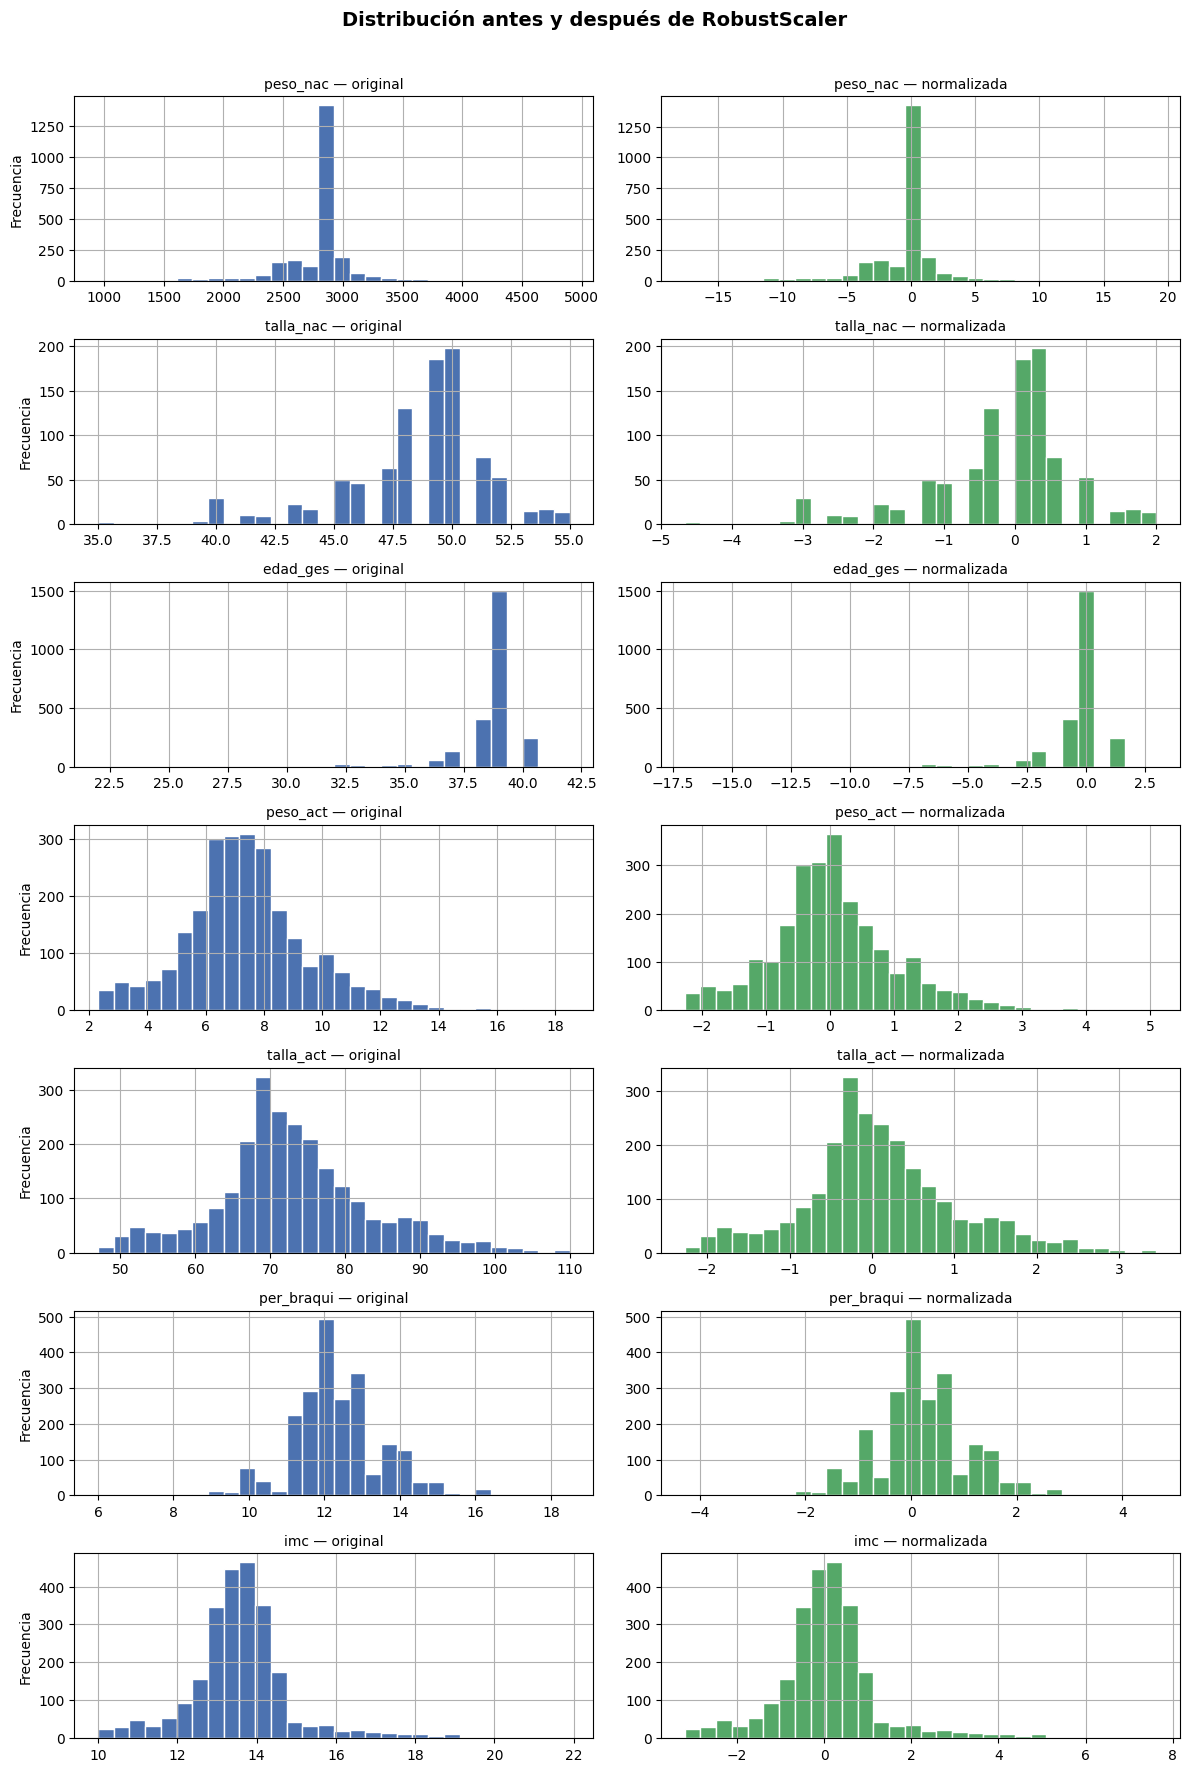


Nota: Los NaN se conservan en data_normalizado tal como estaban en data_unificado.


In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(cols_a_normalizar), 2, figsize=(12, len(cols_a_normalizar) * 2.5))
fig.suptitle("Distribución antes y después de RobustScaler", fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(cols_a_normalizar):
    # Antes
    data_unificado[col].dropna().hist(ax=axes[i, 0], bins=30, color="#4C72B0", edgecolor="white")
    axes[i, 0].set_title(f"{col} — original", fontsize=10)
    axes[i, 0].set_ylabel("Frecuencia")

    # Después
    data_normalizado[col].dropna().hist(ax=axes[i, 1], bins=30, color="#55A868", edgecolor="white")
    axes[i, 1].set_title(f"{col} — normalizada", fontsize=10)

plt.tight_layout()
plt.show()
print("\nNota: Los NaN se conservan en data_normalizado tal como estaban en data_unificado.")

## Exportar dataset limpio unificado

In [62]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Guardar dataset limpio sin normalizar
ruta_limpio = "../data/processed/113_limpio_unificado.csv"
data_unificado.to_csv(ruta_limpio, index=False)
print(f"Dataset limpio guardado en: {ruta_limpio}")
print(f"Shape: {data_unificado.shape}")

# Guardar dataset normalizado
ruta_norm = "../data/processed/113_normalizado.csv"
data_normalizado.to_csv(ruta_norm, index=False)
print(f"\nDataset normalizado guardado en: {ruta_norm}")
print(f"Shape: {data_normalizado.shape}")

Dataset limpio guardado en: ../data/processed/113_limpio_unificado.csv
Shape: (2448, 36)

Dataset normalizado guardado en: ../data/processed/113_normalizado.csv
Shape: (2448, 36)
